# Multimodal Book Genre Classification
## Deep Learning & Neural Networks – Fall 2026

**Pipeline Architecture**

```
TEXT
├── Clean Text
├── TF-IDF
│   ├── Logistic Regression
│   └── SVM
└── Tokenization → Embedding → LSTM

IMAGE
├── Resize (224×224)
├── CNN
└── ResNet50

FUSION
├── Text Features (TF-IDF)
├── Image Features (CNN + ResNet)
└── Random Forest

EVALUATION
├── Accuracy
├── Precision / Recall / F1
└── Confusion Matrix
```

## 1 · Dataset Collection
The cell below was used **once** to scrape book metadata and cover images from the Open Library API and save them to `dataset/books_dataset.csv`. It is kept for reproducibility but is **commented out** — the saved CSV is loaded directly in Section 3.

In [52]:
# ─── Dataset collection script (run once, kept for reference) ───────────────
import requests, time, os, pandas as pd
from requests.exceptions import RequestException

'''
BASE_SEARCH_URL = "https://openlibrary.org/search.json"
BASE_WORK_URL   = "https://openlibrary.org{}"
COVER_URL       = "https://covers.openlibrary.org/b/id/{}-M.jpg"

CATEGORIES = ["psychology", "children", "travel", "self-help", "business", "education"]
LIMIT, SLEEP_TIME, MAX_BOOKS_PER_CATEGORY = 50, 0.5, 200

OUTPUT_DIR = "dataset"
IMAGE_DIR  = os.path.join(OUTPUT_DIR, "images")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR,  exist_ok=True)

all_data = []

def safe_get(url, params=None):
    try:
        return requests.get(url, params=params, timeout=15)
    except RequestException as e:
        print(f"Request failed: {e}")
        return None

def fetch_books(category, page):
    params  = {"q": f"subject:{category} AND language:eng", "limit": LIMIT, "page": page}
    resp    = safe_get(BASE_SEARCH_URL, params=params)
    return resp.json() if resp else {"docs": []}

def fetch_description(work_key):
    resp = safe_get(BASE_WORK_URL.format(work_key + ".json"))
    if resp is None:
        return ""
    data = resp.json()
    desc = data.get("description")
    if isinstance(desc, dict): return desc.get("value", "")
    return desc if isinstance(desc, str) else ""

def download_image(cover_id, filename):
    path = os.path.join(IMAGE_DIR, filename)
    if os.path.exists(path):
        return path
    resp = safe_get(COVER_URL.format(cover_id))
    if resp is None or resp.status_code != 200:
        return None
    with open(path, "wb") as f:
        f.write(resp.content)
    time.sleep(0.1)
    return path

for category in CATEGORIES:
    print(f"\nProcessing: {category}")
    page = 1
    while True:
        if len([x for x in all_data if x["category"] == category]) >= MAX_BOOKS_PER_CATEGORY:
            break
        data  = fetch_books(category, page)
        books = data.get("docs", [])
        if not books:
            break
        for book in books:
            title, work_key, cover_id = book.get("title"), book.get("key"), book.get("cover_i")
            if not all([title, work_key, cover_id]):
                continue
            description = fetch_description(work_key)
            if not description:
                continue
            img_filename = f"{category}_{cover_id}.jpg"
            img_path     = download_image(cover_id, img_filename)
            if not img_path:
                continue
            all_data.append({"title": title, "description": description,
                             "image_path": img_path, "category": category})
        page += 1
        time.sleep(SLEEP_TIME)

df = pd.DataFrame(all_data)
df.to_csv(os.path.join(OUTPUT_DIR, "books_dataset.csv"), index=False)
print("Dataset saved. Shape:", df.shape)
'''
print("Dataset collection cell (skipped – CSV already saved).")


Dataset collection cell (skipped – CSV already saved).


## 2 · Imports

In [53]:
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input as resnet_preprocess_input,
)

from PIL import Image

print("TensorFlow  :", tf.__version__)
print("GPUs found  :", tf.config.list_physical_devices("GPU"))
import torch
print("PyTorch     :", torch.__version__)
print("CUDA via PyTorch:", torch.cuda.is_available())


TensorFlow  : 2.19.0
GPUs found  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch     : 2.10.0+cu128
CUDA via PyTorch: True


## 3 · Configuration & Seeds

In [54]:
import os

print(os.listdir("/kaggle/input/datasets/xzt1abdelrahman"))

['books-dataset']


In [55]:
# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset"
CSV_PATH  = os.path.join(DATA_DIR, "books_dataset.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "images")
# ── Column names ──────────────────────────────────────────────────────────
TEXT_COL  = "description"
TITLE_COL = "title"
IMAGE_COL = "image_path" # contains names of cols inside the df
LABEL_COL = "category"

# ── Model hyperparameters ─────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
MAX_WORDS  = 20_000   # TF-IDF / Tokenizer vocabulary size
MAX_LEN    = 200      # max token sequence length for LSTM

EPOCHS_TEXT  = 6      # LSTM
EPOCHS_IMAGE = 6      # CNN / ResNet50

print("Configuration ready.")
print(f"  CSV  : {CSV_PATH}")
print(f"  Images: {IMAGE_DIR}")


Configuration ready.
  CSV  : /kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/books_dataset.csv
  Images: /kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/images


## 4 · Helper Functions

In [56]:
# ── Text cleaning ─────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """Lowercase, strip HTML/URLs, remove punctuation, collapse whitespace."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<.*?>",         " ", text)   # HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text) # URLs
    text = re.sub(r"[^a-z0-9\s]",   " ", text)   # punctuation
    text = re.sub(r"\s+",            " ", text).strip()
    return text


# ── Image path resolver ────────────────────────────────────────────────────
# ── Image path resolver ───────────────────────────────────────
def ensure_image_path(path: str) -> str:

    if pd.isna(path):
        return ""

    filename = os.path.basename(
        str(path).replace("\\", "/")
    )

    full_path = os.path.join(IMAGE_DIR, filename)

    return full_path


# ── Evaluation helpers ─────────────────────────────────────────────────────
def print_report(y_true, y_pred, label_encoder, title="Model"):
    """Print accuracy + full classification report and return (accuracy, cm)."""
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f} %)")
    print()
    print(classification_report(y_true, y_pred,
                                target_names=label_encoder.classes_,
                                digits=4))
    cm_mat = confusion_matrix(y_true, y_pred)
    return acc, cm_mat


def plot_confusion(cm_mat, labels, title="Confusion Matrix"):
    """Display a colour-mapped confusion matrix with per-cell counts."""
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_mat, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ticks = np.arange(len(labels))
    ax.set_xticks(ticks);  ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(ticks);  ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label",      fontsize=11)
    ax.set_title(title,              fontsize=13)

    thresh = cm_mat.max() / 2
    for i in range(cm_mat.shape[0]):
        for j in range(cm_mat.shape[1]):
            ax.text(j, i, format(cm_mat[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm_mat[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()


def plot_history(history, title="Training History"):
    """Plot train vs validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["loss"],     label="Train loss")
    axes[0].plot(history.history["val_loss"], label="Val  loss")
    axes[0].set_title(f"{title} – Loss");  axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history["accuracy"],     label="Train acc")
    axes[1].plot(history.history["val_accuracy"], label="Val  acc")
    axes[1].set_title(f"{title} – Accuracy"); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")


Helper functions defined.


## 5 · Load Data & Train / Validation / Test Split

The dataset is split **stratified** to preserve class balance at every stage:

| Split      | Proportion | Purpose                          |
|------------|-----------|----------------------------------|
| **Train**  | ~72 %     | Fit all models                   |
| **Val**    | ~8 %      | Early stopping / hyperparameter tuning |
| **Test**   | 20 %      | Final, unbiased evaluation       |

In [64]:
def load_and_prepare_dataframe( csv_path: str):
    """Load CSV, clean text, resolve image paths, encode labels."""
    df = pd.read_csv("/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/books_dataset.csv")

    required = {TITLE_COL, TEXT_COL, IMAGE_COL, LABEL_COL}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    df = df.copy()
    df[TEXT_COL]  = df[TEXT_COL].fillna("")
    df[TITLE_COL] = df[TITLE_COL].fillna("")
    
    df[IMAGE_COL] = df[IMAGE_COL].apply(ensure_image_path)
    
    



    # Combine title + description as the text input for all text models
    df["text_input"] = (
        df[TITLE_COL].astype(str) + " " + df[TEXT_COL].astype(str)
    ).apply(clean_text)

    # Encode string labels → integers
    le = LabelEncoder()
    df["label"] = le.fit_transform(df[LABEL_COL])
    print(df[["category", "label"]].head())
    return df, le


# ── Load ───────────────────────────────────────────────────────────────────
df, label_encoder = load_and_prepare_dataframe(CSV_PATH)
num_classes = len(label_encoder.classes_)

print(f"Rows after cleaning : {len(df)}")
print(f"Classes ({num_classes}): {list(label_encoder.classes_)}")
print()
print(df.groupby(LABEL_COL).size().rename("count"))


     category  label
0  psychology      3
1  psychology      3
2  psychology      3
3  psychology      3
4  psychology      3
Rows after cleaning : 1375
Classes (6): ['business', 'children', 'education', 'psychology', 'self-help', 'travel']

category
business      225
children      234
education     224
psychology    243
self-help     221
travel        228
Name: count, dtype: int64


In [65]:
print(df.columns)

Index(['title', 'description', 'image_path', 'category', 'text_input',
       'label'],
      dtype='object')


In [60]:
for original, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{original} --> {encoded}")

business --> 0
children --> 1
education --> 2
psychology --> 3
self-help --> 4
travel --> 5


In [61]:
df = pd.read_csv("/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/books_dataset.csv")
df.tail()

,title,description,image_path,category
1370,Amber Brown Is Not a Crayon,The year she is in the third grade is a sad ti...,dataset\images\education_10239071.jpg,education
1371,The Story of Ruby Bridges,For months six-year-old Ruby Bridges must conf...,dataset\images\education_4634939.jpg,education
1372,Die Verwirrungen des Zöglings Törless,The Confusions of Young Törless (German: Die V...,dataset\images\education_6804658.jpg,education
1373,The End of Everything (Astrophysically Speaking),**From one of the most dynamic rising stars in...,dataset\images\education_10342810.jpg,education
1374,Some thoughts concerning education,This volume offers two complementary works by ...,dataset\images\education_6108786.jpg,education


In [66]:
# ── Train / Val / Test split ──────────────────────────────────────────────
#
#   Step 1 : hold out 20 % as the test set  (stratified)
#   Step 2 : from the remaining 80 %, hold out 10 % as validation
#             → 0.10 × 0.80 = 8 % of total goes to val
#             → 0.90 × 0.80 = 72 % of total goes to train
#
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"],
)

# Reset indices so ImageDataGenerator doesn't skip rows
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5} rows")
print(f"Val   : {len(val_df):>5} rows")
print(f"Test  : {len(test_df):>5} rows")
print(f"Total : {len(train_df)+len(val_df)+len(test_df):>5} rows")

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values


Train :   990 rows
Val   :   110 rows
Test  :   275 rows
Total :  1375 rows


In [67]:
print(train_df[IMAGE_COL].head())

print("\nExists?")
print(os.path.exists(train_df[IMAGE_COL].iloc[0]))

0    /kaggle/input/datasets/xzt1abdelrahman/books-d...
1    /kaggle/input/datasets/xzt1abdelrahman/books-d...
2    /kaggle/input/datasets/xzt1abdelrahman/books-d...
3    /kaggle/input/datasets/xzt1abdelrahman/books-d...
4    /kaggle/input/datasets/xzt1abdelrahman/books-d...
Name: image_path, dtype: object

Exists?
True


## 6 · Text Models

### 6.1 · TF-IDF Feature Extraction (shared by LR and SVM)

The **TF-IDF vectorizer** is fitted on the *training set only* to prevent data leakage. The same fitted vectorizer transforms validation and test sets.

In [68]:
X_train_text = train_df["text_input"].values
X_val_text   = val_df["text_input"].values
X_test_text  = test_df["text_input"].values

vectorizer = TfidfVectorizer(
    max_features=5_000,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words="english",
    sublinear_tf=True,    # replace tf with 1 + log(tf) for variance reduction
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)   # fit only on train
X_val_tfidf   = vectorizer.transform(X_val_text)
X_test_tfidf  = vectorizer.transform(X_test_text)

print("TF-IDF shapes:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")


TF-IDF shapes:
  Train : (990, 5000)
  Val   : (110, 5000)
  Test  : (275, 5000)


### 6.2 · TF-IDF + Logistic Regression

── Validation ──

  TF-IDF + Logistic Regression [Val]
  Accuracy : 0.4727  (47.27 %)

              precision    recall  f1-score   support

    business     0.6500    0.7222    0.6842        18
    children     0.4444    0.4211    0.4324        19
   education     0.5000    0.3333    0.4000        18
  psychology     0.2963    0.4211    0.3478        19
   self-help     0.6667    0.5556    0.6061        18
      travel     0.3889    0.3889    0.3889        18

    accuracy                         0.4727       110
   macro avg     0.4910    0.4737    0.4766       110
weighted avg     0.4889    0.4727    0.4750       110


── Test ──

  TF-IDF + Logistic Regression [Test]
  Accuracy : 0.4909  (49.09 %)

              precision    recall  f1-score   support

    business     0.5682    0.5556    0.5618        45
    children     0.4792    0.4894    0.4842        47
   education     0.4681    0.4889    0.4783        45
  psychology     0.5000    0.5208    0.5102        48
   self-help    

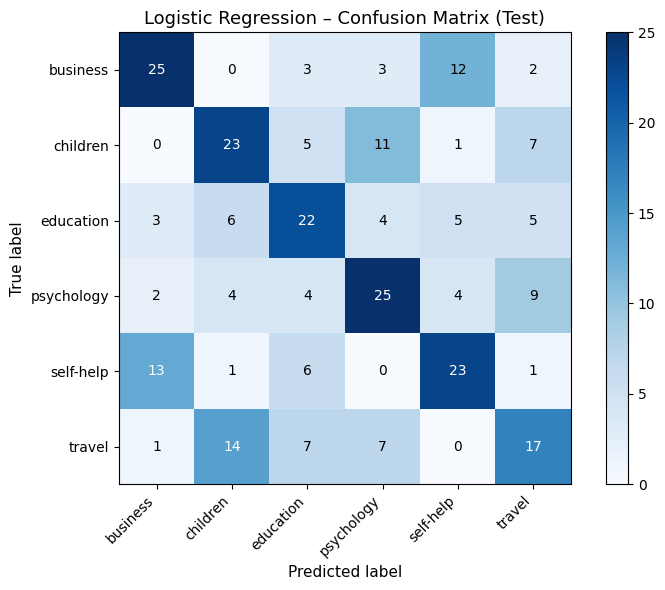

In [69]:
log_reg = LogisticRegression(
    C=5.0,
    max_iter=3_000,
    solver="lbfgs",
    multi_class="auto",
    random_state=SEED,
)
log_reg.fit(X_train_tfidf, y_train)

# Validation performance (used for model comparison / tuning)
y_pred_lr_val = log_reg.predict(X_val_tfidf)
print("── Validation ──")
acc_lr_val, _ = print_report(y_val, y_pred_lr_val, label_encoder,
                              title="TF-IDF + Logistic Regression [Val]")

# Final test evaluation
y_pred_lr = log_reg.predict(X_test_tfidf)
print("\n── Test ──")
acc_lr, cm_lr = print_report(y_test, y_pred_lr, label_encoder,
                             title="TF-IDF + Logistic Regression [Test]")
plot_confusion(cm_lr, label_encoder.classes_,
               title="Logistic Regression – Confusion Matrix (Test)")


### 6.3 · TF-IDF + SVM (LinearSVC)

── Validation ──

  TF-IDF + SVM [Val]
  Accuracy : 0.4455  (44.55 %)

              precision    recall  f1-score   support

    business     0.7000    0.7778    0.7368        18
    children     0.3684    0.3684    0.3684        19
   education     0.6000    0.3333    0.4286        18
  psychology     0.2400    0.3158    0.2727        19
   self-help     0.5556    0.5556    0.5556        18
      travel     0.3333    0.3333    0.3333        18

    accuracy                         0.4455       110
   macro avg     0.4662    0.4474    0.4492       110
weighted avg     0.4633    0.4455    0.4469       110


── Test ──

  TF-IDF + SVM [Test]
  Accuracy : 0.4800  (48.00 %)

              precision    recall  f1-score   support

    business     0.5814    0.5556    0.5682        45
    children     0.4694    0.4894    0.4792        47
   education     0.4375    0.4667    0.4516        45
  psychology     0.4894    0.4792    0.4842        48
   self-help     0.5000    0.5455    0.5217     

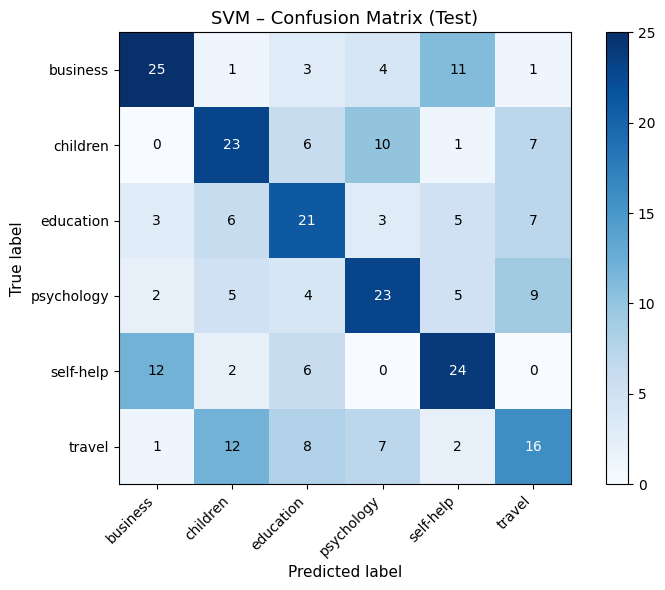

In [70]:
svm = LinearSVC(C=1.0, max_iter=5_000, random_state=SEED)
svm.fit(X_train_tfidf, y_train)

y_pred_svm_val = svm.predict(X_val_tfidf)
print("── Validation ──")
acc_svm_val, _ = print_report(y_val, y_pred_svm_val, label_encoder,
                               title="TF-IDF + SVM [Val]")

y_pred_svm = svm.predict(X_test_tfidf)
print("\n── Test ──")
acc_svm, cm_svm = print_report(y_test, y_pred_svm, label_encoder,
                               title="TF-IDF + SVM [Test]")
plot_confusion(cm_svm, label_encoder.classes_,
               title="SVM – Confusion Matrix (Test)")


### 6.4 · Tokenization → Embedding → BiLSTM

A bidirectional LSTM reads book text in both directions to capture context from the full description. `EarlyStopping` on `val_loss` prevents overfitting.

In [71]:
# ── Tokenisation ─────────────────────────────────────────────────────────
tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(train_df["text_input"].values)   # fit on train only

train_seq = tokenizer_keras.texts_to_sequences(train_df["text_input"].values)
val_seq   = tokenizer_keras.texts_to_sequences(val_df["text_input"].values)
test_seq  = tokenizer_keras.texts_to_sequences(test_df["text_input"].values)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded sequence shapes:")
print(f"  Train : {X_train_pad.shape}")
print(f"  Val   : {X_val_pad.shape}")
print(f"  Test  : {X_test_pad.shape}")


Padded sequence shapes:
  Train : (990, 200)
  Val   : (110, 200)
  Test  : (275, 200)


In [72]:
# ── BiLSTM model ──────────────────────────────────────────────────────────
lstm_model = models.Sequential([
    layers.Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
], name="BiLSTM")

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
lstm_model.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.1886 - loss: 1.7995 - val_accuracy: 0.2091 - val_loss: 1.7955 - learning_rate: 0.0010
Epoch 2/6
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2313 - loss: 1.7798 - val_accuracy: 0.2273 - val_loss: 1.7645 - learning_rate: 0.0010
Epoch 3/6
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3698 - loss: 1.6478 - val_accuracy: 0.2455 - val_loss: 1.6533 - learning_rate: 0.0010
Epoch 4/6
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4219 - loss: 1.3468
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4220 - loss: 1.3453 - val_accuracy: 0.2636 - val_loss: 1.6786 - learning_rate: 0.0010
Epoch 5/6
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5357 - loss: 1.0870
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5359 - loss: 1.0861 - val_accuracy: 

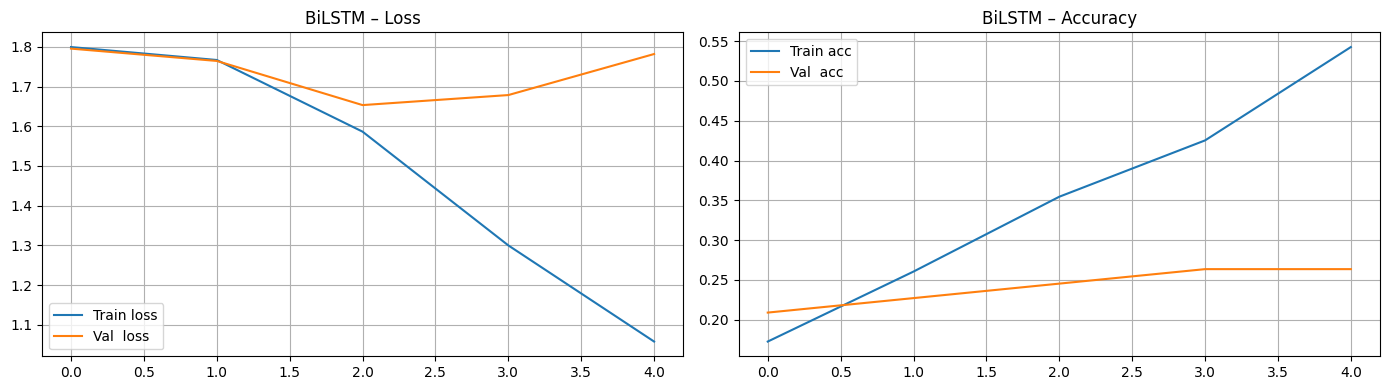

In [73]:
lstm_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=2,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=1, min_lr=1e-6, verbose=1),
]

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_TEXT,
    batch_size=32,
    callbacks=lstm_callbacks,
    verbose=1,
)

plot_history(lstm_history, title="BiLSTM")



  Embedding + BiLSTM [Test]
  Accuracy : 0.3345  (33.45 %)

              precision    recall  f1-score   support

    business     0.4375    0.1556    0.2295        45
    children     0.3544    0.5957    0.4444        47
   education     0.2373    0.3111    0.2692        45
  psychology     0.2143    0.1250    0.1579        48
   self-help     0.3780    0.7045    0.4921        44
      travel     0.5455    0.1304    0.2105        46

    accuracy                         0.3345       275
   macro avg     0.3612    0.3371    0.3006       275
weighted avg     0.3601    0.3345    0.2991       275



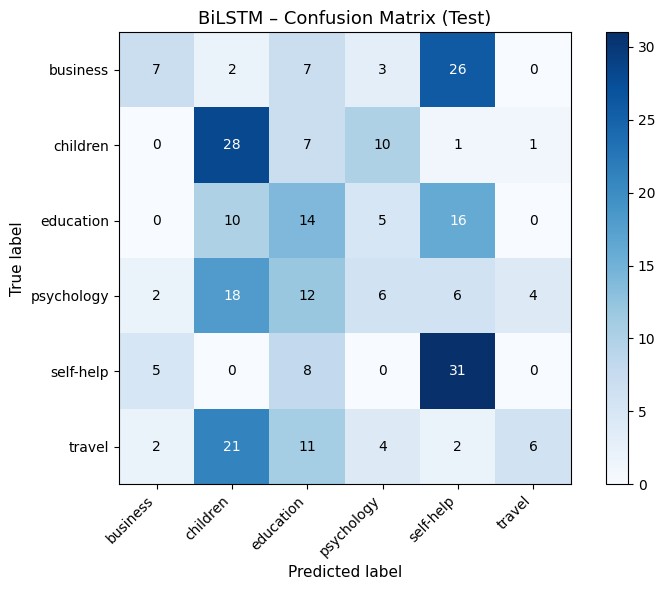

In [74]:
lstm_probs = lstm_model.predict(X_test_pad, verbose=0)
lstm_pred  = np.argmax(lstm_probs, axis=1)

acc_lstm, cm_lstm = print_report(y_test, lstm_pred, label_encoder,
                                 title="Embedding + BiLSTM [Test]")
plot_confusion(cm_lstm, label_encoder.classes_,
               title="BiLSTM – Confusion Matrix (Test)")


## 7 · Image Models

All images are resized to **224 × 224** to match the expected input of ResNet50 (and to keep the custom CNN consistent). `ImageDataGenerator` provides inline preprocessing and optional augmentation.

### 7.1 · Data Generators

In [75]:
print(df[IMAGE_COL].head())

print(os.path.exists(df[IMAGE_COL].iloc[0]))

0    /kaggle/input/datasets/xzt1abdelrahman/books-d...
1    /kaggle/input/datasets/xzt1abdelrahman/books-d...
2    /kaggle/input/datasets/xzt1abdelrahman/books-d...
3    /kaggle/input/datasets/xzt1abdelrahman/books-d...
4    /kaggle/input/datasets/xzt1abdelrahman/books-d...
Name: image_path, dtype: object
True


In [76]:
print(train_df[IMAGE_COL].head())

sample = train_df[IMAGE_COL].iloc[0]

print("\nSample:")
print(sample)

print("\nExists:")
print(os.path.exists(sample))

0    /kaggle/input/datasets/xzt1abdelrahman/books-d...
1    /kaggle/input/datasets/xzt1abdelrahman/books-d...
2    /kaggle/input/datasets/xzt1abdelrahman/books-d...
3    /kaggle/input/datasets/xzt1abdelrahman/books-d...
4    /kaggle/input/datasets/xzt1abdelrahman/books-d...
Name: image_path, dtype: object

Sample:
/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/images/psychology_5517733.jpg

Exists:
True


In [77]:
# ── Generators for simple CNN (rescale only) ──────────────────────────────
cnn_train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,       # light augmentation to reduce overfitting
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
)
cnn_val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

def make_gen_cnn(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe,
        x_col=IMAGE_COL,
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="raw",
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_gen_cnn = make_gen_cnn(cnn_train_datagen,    train_df, shuffle=True)
val_gen_cnn   = make_gen_cnn(cnn_val_test_datagen, val_df,   shuffle=False)
test_gen_cnn  = make_gen_cnn(cnn_val_test_datagen, test_df,  shuffle=False)


# ── Generators for ResNet50 (ResNet-specific preprocessing) ───────────────
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
)
resnet_val_test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input,
)

def make_gen_resnet(datagen, dataframe, shuffle, include_labels=True):
    return datagen.flow_from_dataframe(
        dataframe,
        x_col=IMAGE_COL,
        y_col="label" if include_labels else None,
        target_size=IMG_SIZE,
        class_mode="raw" if include_labels else None,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_gen_resnet = make_gen_resnet(resnet_train_datagen,    train_df, shuffle=True)
val_gen_resnet   = make_gen_resnet(resnet_val_test_datagen, val_df,   shuffle=False)
test_gen_resnet  = make_gen_resnet(resnet_val_test_datagen, test_df,  shuffle=False)


Found 990 validated image filenames.
Found 110 validated image filenames.
Found 275 validated image filenames.
Found 990 validated image filenames.
Found 110 validated image filenames.
Found 275 validated image filenames.


In [78]:
print(DATA_DIR)

print(os.path.exists(DATA_DIR))

print(IMAGE_DIR)

print(os.path.exists(IMAGE_DIR))

/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset
True
/kaggle/input/datasets/xzt1abdelrahman/books-dataset/dataset/images
True


In [79]:
print(os.listdir(IMAGE_DIR)[:5])

['psychology_10521439.jpg', 'psychology_9255997.jpg', 'psychology_799531.jpg', 'self-help_5360049.jpg', 'business_12374726.jpg']


In [80]:
print(df[IMAGE_COL].head())

0    /kaggle/input/datasets/xzt1abdelrahman/books-d...
1    /kaggle/input/datasets/xzt1abdelrahman/books-d...
2    /kaggle/input/datasets/xzt1abdelrahman/books-d...
3    /kaggle/input/datasets/xzt1abdelrahman/books-d...
4    /kaggle/input/datasets/xzt1abdelrahman/books-d...
Name: image_path, dtype: object


### 7.2 · Custom CNN

In [81]:
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
], name="CustomCNN")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.2221 - loss: 2.1140 - val_accuracy: 0.1636 - val_loss: 1.8853 - learning_rate: 0.0010
Epoch 2/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2133 - loss: 1.9278
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.2130 - loss: 1.9279 - val_accuracy: 0.1818 - val_loss: 2.0945 - learning_rate: 0.0010
Epoch 3/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2410 - loss: 1.8437
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.2408 - loss: 1.8438 - val_accuracy: 0.2091 - val_loss: 1.9500 - learning_rate: 5.0000e-04
Epoch 4/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.2606 - loss: 1.7982
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.2606 - loss: 1.7980 -

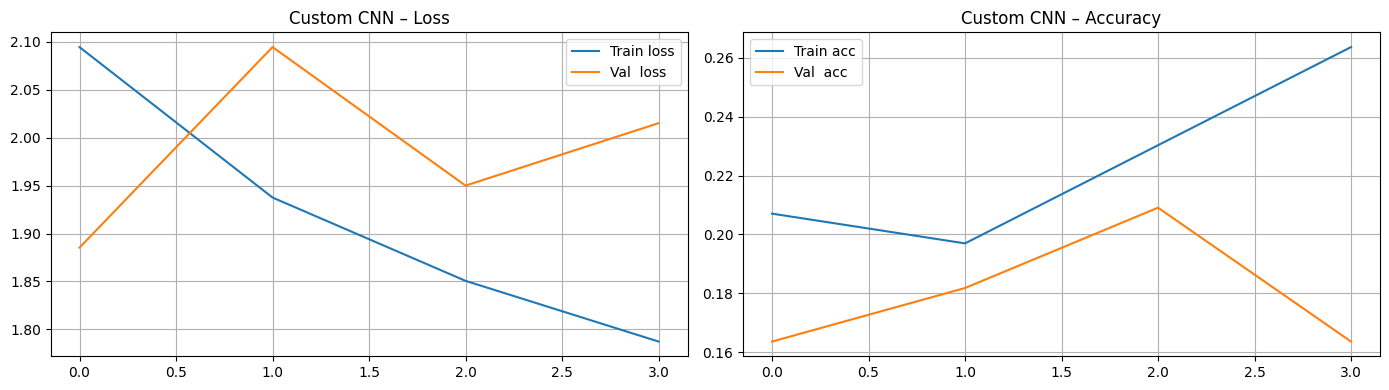

In [82]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=1, min_lr=1e-6, verbose=1),
]

cnn_history = cnn_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS_IMAGE,
    callbacks=cnn_callbacks,
    verbose=1,
)

plot_history(cnn_history, title="Custom CNN")



  Custom CNN [Test]
  Accuracy : 0.1600  (16.00 %)

              precision    recall  f1-score   support

    business     0.0000    0.0000    0.0000        45
    children     0.1786    0.4255    0.2516        47
   education     0.0000    0.0000    0.0000        45
  psychology     0.0000    0.0000    0.0000        48
   self-help     0.1472    0.5455    0.2319        44
      travel     0.0000    0.0000    0.0000        46

    accuracy                         0.1600       275
   macro avg     0.0543    0.1618    0.0806       275
weighted avg     0.0541    0.1600    0.0801       275



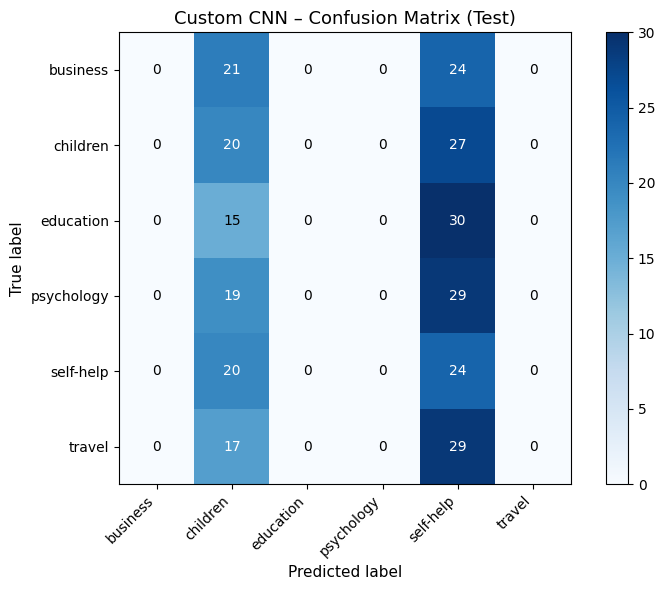

In [83]:
cnn_probs = cnn_model.predict(test_gen_cnn, verbose=0)
cnn_pred  = np.argmax(cnn_probs, axis=1)

acc_cnn, cm_cnn = print_report(y_test, cnn_pred, label_encoder,
                               title="Custom CNN [Test]")
plot_confusion(cm_cnn, label_encoder.classes_,
               title="Custom CNN – Confusion Matrix (Test)")


### 7.3 · ResNet50 (Transfer Learning)

The ResNet50 backbone pre-trained on ImageNet is **frozen** (feature extractor). Only the added classification head is trained, which is efficient and leverages powerful visual representations learned on millions of images.

In [84]:
base_resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling="avg",          # Global Average Pooling → 2048-dim feature vector
)
base_resnet.trainable = False   # Freeze backbone

resnet_model = models.Sequential([
    base_resnet,
    layers.Dense(512, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax"),
], name="ResNet50_Transfer")

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
resnet_model.summary()


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,878 (93.99 MB)

 Trainable params: 1,052,166 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 324ms/step - accuracy: 0.2352 - loss: 2.6192 - val_accuracy: 0.3091 - val_loss: 1.9008 - learning_rate: 0.0010
Epoch 2/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.3727 - loss: 1.6312 - val_accuracy: 0.2909 - val_loss: 1.7911 - learning_rate: 0.0010
Epoch 3/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.4539 - loss: 1.4326 - val_accuracy: 0.2909 - val_loss: 1.7591 - learning_rate: 0.0010
Epoch 4/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5079 - loss: 1.3377
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.5078 - loss: 1.3375 - val_accuracy: 0.2909 - val_loss: 1.8427 - learning_rate: 0.0010
Epoch 5/6
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5684 - loss: 1.1515
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.5681 - loss: 1.1523 - va

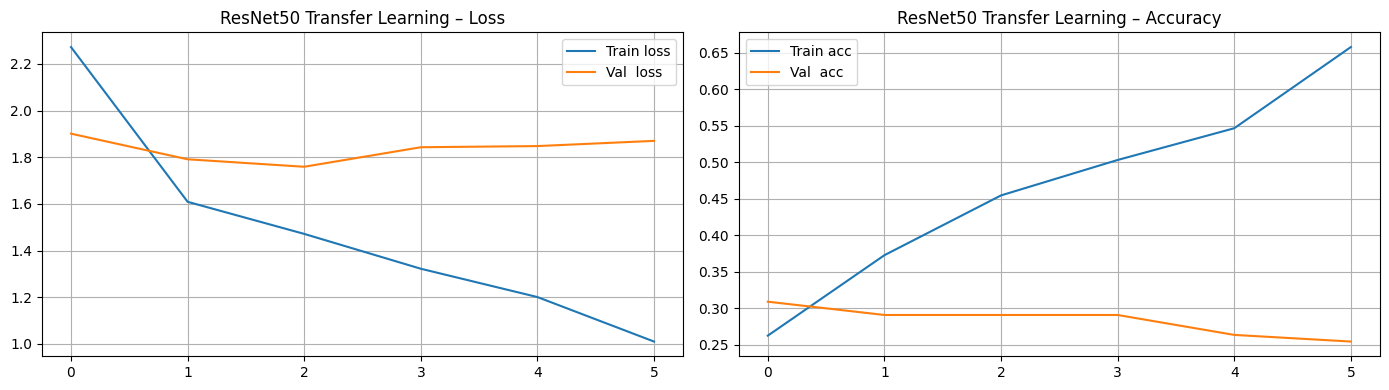

In [85]:
resnet_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=1, min_lr=1e-6, verbose=1),
]

resnet_history = resnet_model.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=EPOCHS_IMAGE,
    callbacks=resnet_callbacks,
    verbose=1,
)

plot_history(resnet_history, title="ResNet50 Transfer Learning")


In [86]:
print("Kernel/session is alive.")

try:
    print("\nDF shape:", df.shape)
    print("Train DF shape:", train_df.shape)

    print("\nGPU check:")
    print(tf.config.list_physical_devices('GPU'))

    print("\nSample image exists:")
    print(os.path.exists(train_df[IMAGE_COL].iloc[0]))

    print("\nSession variables still exist ✅")

except NameError as e:
    print("\nSession was likely reset ❌")
    print(e)

Kernel/session is alive.

DF shape: (1375, 6)
Train DF shape: (990, 6)

GPU check:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Sample image exists:
True

Session variables still exist ✅



  ResNet50 [Test]
  Accuracy : 0.3564  (35.64 %)

              precision    recall  f1-score   support

    business     0.3833    0.5111    0.4381        45
    children     0.3636    0.4255    0.3922        47
   education     0.5000    0.1556    0.2373        45
  psychology     0.2069    0.1250    0.1558        48
   self-help     0.4815    0.2955    0.3662        44
      travel     0.3222    0.6304    0.4265        46

    accuracy                         0.3564       275
   macro avg     0.3763    0.3572    0.3360       275
weighted avg     0.3737    0.3564    0.3347       275



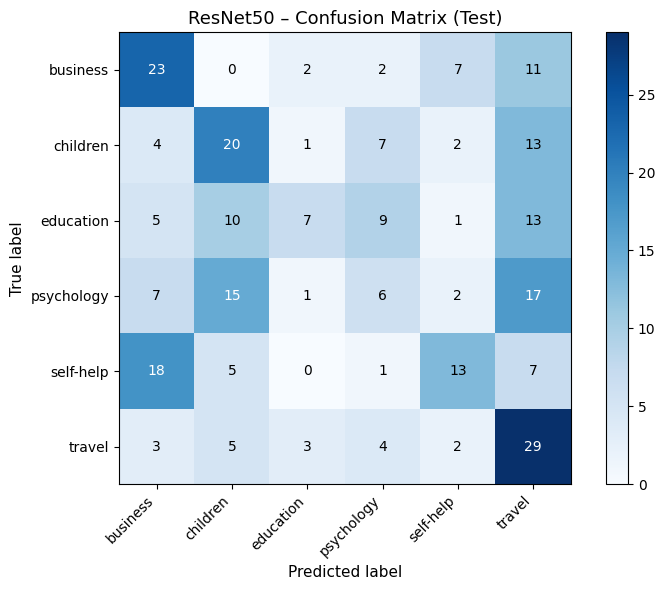

In [87]:
resnet_probs = resnet_model.predict(test_gen_resnet, verbose=0)
resnet_pred  = np.argmax(resnet_probs, axis=1)

acc_resnet, cm_resnet = print_report(y_test, resnet_pred, label_encoder,
                                     title="ResNet50 [Test]")
plot_confusion(cm_resnet, label_encoder.classes_,
               title="ResNet50 – Confusion Matrix (Test)")

## 8 · Fusion Model – TF-IDF + ResNet Features → Random Forest

The fusion model **combines** two complementary modalities:
- **Text** : TF-IDF sparse matrix → reduced to 300 dense dimensions via Truncated SVD (LSA)
- **Image** : 2048-dimensional global-average-pooling features extracted from the frozen ResNet50 backbone

The concatenated feature vector is fed into a **Random Forest**, which handles high-dimensional tabular data robustly without additional normalisation.

In [88]:
# ── Step 1 : Reduce TF-IDF to dense vectors via Truncated SVD ────────────
print("Reducing TF-IDF with Truncated SVD …")
svd = TruncatedSVD(n_components=300, random_state=SEED)
X_train_tfidf_dense = svd.fit_transform(X_train_tfidf)   # fit on train
X_val_tfidf_dense   = svd.transform(X_val_tfidf)
X_test_tfidf_dense  = svd.transform(X_test_tfidf)

print(f"  TF-IDF dense (train) : {X_train_tfidf_dense.shape}")
print(f"  Explained variance   : {svd.explained_variance_ratio_.sum():.3f}")


Reducing TF-IDF with Truncated SVD …
  TF-IDF dense (train) : (990, 300)
  Explained variance   : 0.589


In [89]:
# ── Step 2 : Extract ResNet50 image features ──────────────────────────────
print("Extracting ResNet50 image features …")

# Use the frozen backbone directly as a feature extractor (no classification head)
feature_extractor = tf.keras.Model(
    inputs=base_resnet.input,
    outputs=base_resnet.output,
    name="ResNet50_FeatureExtractor",
)

def extract_resnet_features(dataframe):
    """Return (N, 2048) feature matrix for all images in dataframe."""
    gen = resnet_val_test_datagen.flow_from_dataframe(
        dataframe,
        x_col=IMAGE_COL,
        y_col=None,
        target_size=IMG_SIZE,
        class_mode=None,
        batch_size=BATCH_SIZE,
        shuffle=False,     # MUST be False to keep order consistent with labels
    )
    return feature_extractor.predict(gen, verbose=0)

X_train_img_feat = extract_resnet_features(train_df)
X_val_img_feat   = extract_resnet_features(val_df)
X_test_img_feat  = extract_resnet_features(test_df)

print(f"  Image features (train): {X_train_img_feat.shape}")


Extracting ResNet50 image features …
Found 990 validated image filenames.
Found 110 validated image filenames.
Found 275 validated image filenames.
  Image features (train): (990, 2048)


In [90]:
# ── Step 3 : Concatenate text + image features ────────────────────────────
X_train_fusion = np.hstack([X_train_tfidf_dense, X_train_img_feat])
X_val_fusion   = np.hstack([X_val_tfidf_dense,   X_val_img_feat])
X_test_fusion  = np.hstack([X_test_tfidf_dense,  X_test_img_feat])

print(f"  Fusion feature vector size : {X_train_fusion.shape[1]}")
print(f"    └─ TF-IDF (SVD-300) + ResNet (2048) = {300 + 2048}")


  Fusion feature vector size : 2348
    └─ TF-IDF (SVD-300) + ResNet (2048) = 2348


Training Random Forest …
── Validation ──

  Fusion RF [Val]
  Accuracy : 0.2727  (27.27 %)

              precision    recall  f1-score   support

    business     0.4000    0.3333    0.3636        18
    children     0.3333    0.3684    0.3500        19
   education     0.3750    0.1667    0.2308        18
  psychology     0.0870    0.1053    0.0952        19
   self-help     0.3500    0.3889    0.3684        18
      travel     0.2174    0.2778    0.2439        18

    accuracy                         0.2727       110
   macro avg     0.2938    0.2734    0.2753       110
weighted avg     0.2923    0.2727    0.2744       110


── Test ──

  Fusion: TF-IDF + ResNet → Random Forest [Test]
  Accuracy : 0.3564  (35.64 %)

              precision    recall  f1-score   support

    business     0.4375    0.4667    0.4516        45
    children     0.3538    0.4894    0.4107        47
   education     0.2500    0.1778    0.2078        45
  psychology     0.1628    0.1458    0.1538        48

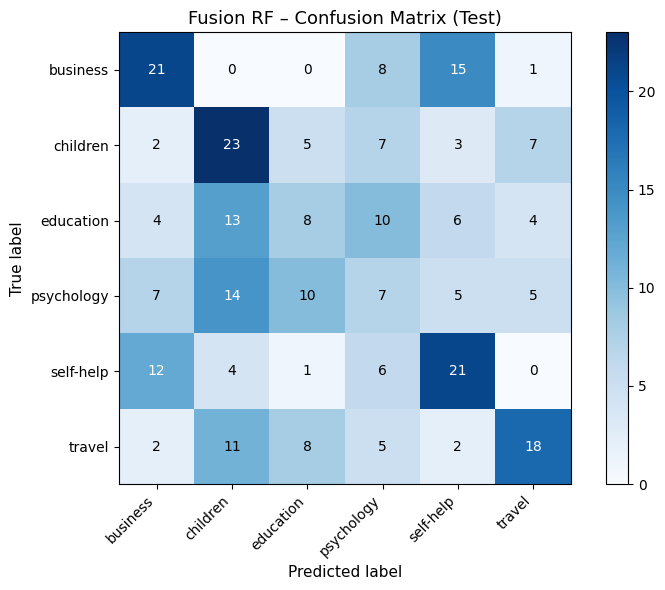

In [91]:
# ── Step 4 : Train Random Forest ──────────────────────────────────────────
print("Training Random Forest …")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
rf.fit(X_train_fusion, y_train)

# Validation
rf_pred_val = rf.predict(X_val_fusion)
print("── Validation ──")
acc_rf_val, _ = print_report(y_val, rf_pred_val, label_encoder,
                              title="Fusion RF [Val]")

# Test
rf_pred = rf.predict(X_test_fusion)
print("\n── Test ──")
acc_rf, cm_rf = print_report(y_test, rf_pred, label_encoder,
                             title="Fusion: TF-IDF + ResNet → Random Forest [Test]")
plot_confusion(cm_rf, label_encoder.classes_,
               title="Fusion RF – Confusion Matrix (Test)")


## 9 · Comparative Analysis

All six models are compared on the **held-out test set** using accuracy as the primary metric. Precision, Recall, and F1 scores are available in the classification reports printed above.

In [92]:
# ── Summary table ─────────────────────────────────────────────────────────
results = pd.DataFrame([
    {"Model": "TF-IDF + Logistic Regression", "Modality": "Text",    "Test Accuracy": acc_lr},
    {"Model": "TF-IDF + SVM",                 "Modality": "Text",    "Test Accuracy": acc_svm},
    {"Model": "Embedding + BiLSTM",           "Modality": "Text",    "Test Accuracy": acc_lstm},
    {"Model": "Custom CNN",                   "Modality": "Image",   "Test Accuracy": acc_cnn},
    {"Model": "ResNet50 (Transfer)",          "Modality": "Image",   "Test Accuracy": acc_resnet},
    {"Model": "Fusion: TF-IDF + ResNet → RF", "Modality": "Fusion",  "Test Accuracy": acc_rf},
])

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results["Test Accuracy (%)"] = (results["Test Accuracy"] * 100).round(2)

print("\n" + "="*65)
print("  FINAL MODEL COMPARISON – Test Set")
print("="*65)
print(results[["Model", "Modality", "Test Accuracy (%)"]].to_string(index=False))
print("="*65)



  FINAL MODEL COMPARISON – Test Set
                       Model Modality  Test Accuracy (%)
TF-IDF + Logistic Regression     Text              49.09
                TF-IDF + SVM     Text              48.00
Fusion: TF-IDF + ResNet → RF   Fusion              35.64
         ResNet50 (Transfer)    Image              35.64
          Embedding + BiLSTM     Text              33.45
                  Custom CNN    Image              16.00


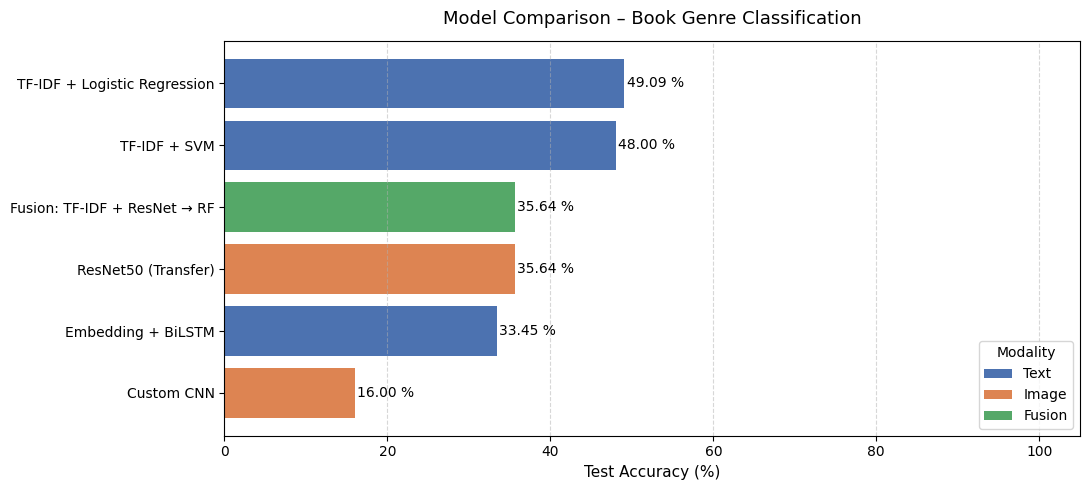

In [93]:
# ── Bar chart ─────────────────────────────────────────────────────────────
palette = {"Text": "#4C72B0", "Image": "#DD8452", "Fusion": "#55A868"}
colours = [palette[m] for m in results["Modality"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(results["Model"], results["Test Accuracy (%)"], color=colours)

for bar, val in zip(bars, results["Test Accuracy (%)"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} %", va="center", fontsize=10)

ax.set_xlabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Model Comparison – Book Genre Classification", fontsize=13, pad=12)
ax.set_xlim(0, 105)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_elements, loc="lower right", title="Modality")

plt.tight_layout()
plt.show()


## 10 · Conclusions

| Modality | Key Takeaway |
|----------|-------------|
| **Text (TF-IDF)**  | Fast, interpretable baselines. LR and SVM provide strong performance relative to their simplicity. |
| **Text (LSTM)**    | Captures sequential semantics; particularly helpful for genre signals embedded in descriptive prose. |
| **Image (CNN)**    | Book covers contain valuable genre cues (colour, typography). The custom CNN captures these with modest data. |
| **Image (ResNet)** | Transfer learning from ImageNet gives a significant accuracy boost over the from-scratch CNN. |
| **Fusion (RF)**    | Combining modalities generally improves over any single-modality model, validating the multimodal approach. |

**Evaluation criteria addressed**

- **Data & Problem Understanding** – dataset cleaned, stratified split with train / val / test
- **Modeling & Architecture Design** – six models across three modalities, justified design choices
- **Implementation & Technical Quality** – modular functions, proper data generators, no leakage
- **Experimental & Comparative Analysis** – all models evaluated on the same test set, results table + chart
- **Evaluation Metrics & Validation Strategy** – accuracy, precision, recall, F1, confusion matrix, training curves
- **Individual Understanding** – comments and docstrings throughout for easy presentation discussion
